<a href="https://colab.research.google.com/github/nataliurena1985/AndroidApp/blob/master/03_2__Reducci%C3%B3n_de_dimensionalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div
<br><br>
<h1 style="color:#7F000E;"> DMC </h1>
<h1 style="color:#7F000E;"> Aprendizaje no Supervisado y algoritmos de clusterización </h1>

<h3 style="color:#7F000E;"> Métodos No Supervisados </h3>
<h3 style="color:#7F000E;"> Algoritmo PCA - Caso practico </h3>
</div>
<br><br>
<div style="text-align:right">

<span style="color:#7F000E; font-size:14px;">Ing. César Quezada</span><br>
<span style="color:#7F000E; font-size:14px;">Horario: 19:00 – 22:00</span><br>
<span style="color:#7F000E; font-size:14px;">Sesión 03</span>

</div>


#### Caso:

Dado que los clientes reciben diversas ofertas de consumo para que estos puedan transaccionar con su tarjeta de crédito y débito, la entidad bancaria no está segura si sus clientes tienen algún interes en sus ofertas, teniendo en cuenta que cada oferta ya corresponde un gasto para la entidad.

Por tanto: Se pide realizar un estudio de segmentación para conocer cuáles son las preferencias de consumo que sus clientes optarían para comunicarles ofertas más direccionadas.

# Caso Práctico

### 1. Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

### 2. Extracción Base de datos

In [ ]:
dataFrame = pd.read_csv("03 archivo_consumo.csv",delimiter=',')
dataFrame.head()

,cliente,edad,ingreso,sexo,**,alqbienes,artcultura,belleza,clubmkt,enseñanza,...,prodpersondiv,prodsuper,profdiverso,restbar,ropamoda,salud,telcom,tiendadepar,transplaerea,vehrep
0,1,[7. > 55],[3. <=2500],M,0.0,1.0,0.0,2.0,0.0,0.0,...,0.0,10.0,0.0,7.0,2.0,3.0,0.0,2.0,0.0,10.0
1,2,[7. > 55],[8. > 8000],M,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,12.0,0.0,33.0,4.0,3.0,0.0,2.0,0.0,0.0
2,3,[7. > 55],[4. <=3500],M,0.0,4.0,0.0,0.0,0.0,0.0,...,2.0,2.0,0.0,11.0,5.0,7.0,1.0,0.0,0.0,8.0
3,4,[7. > 55],[6. <=6000],M,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,27.0,1.0,3.0,0.0,0.0,9.0,1.0,0.0,100.0
4,5,[7. > 55],[6. <=6000],M,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35002 entries, 0 to 35001
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cliente          35002 non-null  int64  
 1   edad             35002 non-null  object 
 2   ingreso          35002 non-null  object 
 3   sexo             35002 non-null  object 
 4   **               35002 non-null  float64
 5   alqbienes        35002 non-null  float64
 6   artcultura       35002 non-null  float64
 7   belleza          35002 non-null  float64
 8   clubmkt          35002 non-null  float64
 9   enseñanza        35002 non-null  float64
 10  entretenimiento  35002 non-null  float64
 11  financiero       35002 non-null  float64
 12  hogaroficina     35002 non-null  float64
 13  informatica      35002 non-null  float64
 14  prodelectro      35002 non-null  float64
 15  prodlocal        35002 non-null  float64
 16  prodpersondiv    35002 non-null  float64
 17  prodsuper   

### 3. Metodología

In [ ]:
#### 3.1 Análisis Previo (objetivo)
#### 3.2 Exploración (descriptivo, grafico barras,cajas)
#### 3.3 Transformación (standarización,cajas)
#### 3.4 Outliers (analisis y eliminación de outliers)
#### 3.5 Dimensionamiento (PCA)
#### 3.6 Modelamiento
#### 3.7 Evaluación
#### 3.8 Perfilamiento
#### 3.9 Visualización

In [ ]:
# Variables objetivo de estudio:
rubroName = ['prodsuper', 'restbar', 'salud', 'vehrep', 'entretenimiento', 'tiendadepar', 'ropamoda', 'prodpersondiv',
               'telcom','financiero', 'transplaerea','clubmkt','prodlocal','enseñanza','belleza','prodelectro',
               'alqbienes','artcultura','profdiverso','hogaroficina','informatica']

In [ ]:
print("Número de filas: " + str(dataFrame.shape[0]))
print("Número de columnas: " + str(dataFrame.shape[1]))

Número de filas: 35002
Número de columnas: 26


#### 3.1 Transformación

In [ ]:
# ------------------------------
# Creamos el objeto para escalar
# ------------------------------
from sklearn import preprocessing

scaler = preprocessing.MinMaxScaler()

# Guardamos el dataframe original
df_real = dataFrame.copy()

# ************
# Lo aplicamos
# ************
for columnName in rubroName:
    dataFrame['tran_'+columnName] = scaler.fit_transform(dataFrame[columnName].values.reshape(-1, 1))

In [ ]:
# Variables objetivo de estudio:
rubroNameTran = ['tran_prodsuper', 'tran_restbar', 'tran_salud', 'tran_vehrep', 'tran_entretenimiento', 'tran_tiendadepar',
                 'tran_ropamoda', 'tran_prodpersondiv', 'tran_telcom','tran_financiero', 'tran_transplaerea','tran_clubmkt',
                 'tran_prodlocal','tran_enseñanza','tran_belleza','tran_prodelectro','tran_alqbienes','tran_artcultura',
                 'tran_profdiverso','tran_hogaroficina','tran_informatica']

In [ ]:
dataFrame[rubroNameTran].head()

,tran_prodsuper,tran_restbar,tran_salud,tran_vehrep,tran_entretenimiento,tran_tiendadepar,tran_ropamoda,tran_prodpersondiv,tran_telcom,tran_financiero,...,tran_clubmkt,tran_prodlocal,tran_enseñanza,tran_belleza,tran_prodelectro,tran_alqbienes,tran_artcultura,tran_profdiverso,tran_hogaroficina,tran_informatica
0,0.030960,0.041667,0.027027,0.038168,0.000000,0.029412,0.021053,0.00,0.000000,0.000000,...,0.0,0.010989,0.000000,0.038462,0.0,0.017241,0.0,0.000000,0.0,0.0
1,0.037152,0.196429,0.027027,0.000000,0.000000,0.029412,0.042105,0.03,0.000000,0.000000,...,0.0,0.000000,0.019608,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
2,0.006192,0.065476,0.063063,0.030534,0.001890,0.000000,0.052632,0.02,0.007194,0.009009,...,0.0,0.000000,0.000000,0.000000,0.0,0.068966,0.0,0.000000,0.0,0.0
3,0.083591,0.017857,0.000000,0.381679,0.005671,0.014706,0.000000,0.02,0.064748,0.171171,...,0.0,0.021978,0.000000,0.000000,0.0,0.000000,0.0,0.035714,0.0,0.0
4,0.009288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0


#### 3.2 Reducción de dimensión (PCA)

In [ ]:
# Calculamos el máximo número de componentes (Nro variables = Nro máximo de componentes)
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(dataFrame[rubroNameTran])
pca.explained_variance_ratio_

array([0.25974372, 0.11323515, 0.07932154, 0.07243894, 0.05978455,
       0.0550162 , 0.04264844, 0.03856483, 0.03627173, 0.03049427,
       0.0298829 , 0.02719705, 0.02677751, 0.02623333, 0.02128671,
       0.01997059, 0.01545035, 0.014765  , 0.01425238, 0.01254701,
       0.00411779])

% Var. explicada (1 componentes):  25.97437200423635
% Var. explicada (2 componentes):  37.29788691774416
% Var. explicada (3 componentes):  45.23004096022733
% Var. explicada (4 componentes):  52.473935005997596
% Var. explicada (5 componentes):  58.452389965399696
% Var. explicada (6 componentes):  63.95400950099312
% Var. explicada (7 componentes):  68.21885363869595
% Var. explicada (8 componentes):  72.07533707996092
% Var. explicada (9 componentes):  75.70250958594963
% Var. explicada (10 componentes):  78.75193700479302
% Var. explicada (11 componentes):  81.7402274419521
% Var. explicada (12 componentes):  84.45993213078505
% Var. explicada (13 componentes):  87.13768348528326
% Var. explicada (14 componentes):  89.76101613211462
% Var. explicada (15 componentes):  91.88968719599137
% Var. explicada (16 componentes):  93.88674627237995
% Var. explicada (17 componentes):  95.43178171573278
% Var. explicada (18 componentes):  96.908282004453
% Var. explicada (19 componentes):  98

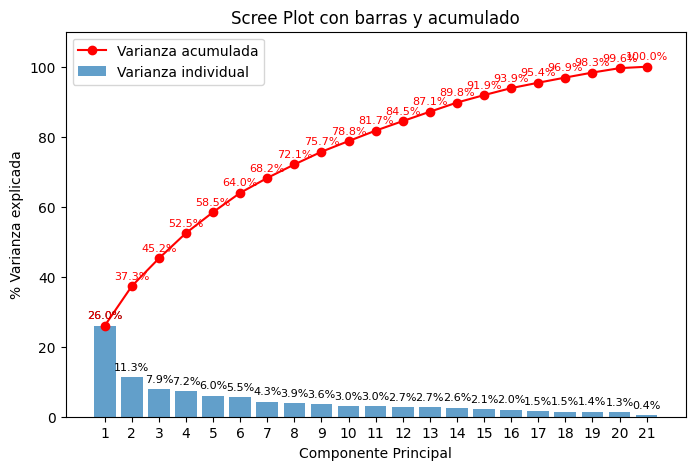

In [ ]:
for i in range(len(pca.components_)):
    print('% Var. explicada ('+str(i+1)+' componentes): ', np.cumsum(pca.explained_variance_ratio_)[i]*100)

# plt.bar(range(1,len(pca.components_)+1),pca.explained_variance_ratio_, alpha=.2,color='0')
# plt.plot(range(1,len(pca.components_)+1),np.cumsum(pca.explained_variance_ratio_),alpha=1)
# plt.title("Varianza explicada y pareto")
# plt.show()

var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

plt.figure(figsize=(8,5))

# Barras
bars = plt.bar(range(1,len(var_exp)+1), var_exp*100, alpha=0.7, label="Varianza individual")

# Línea acumulada
plt.plot(range(1,len(var_exp)+1), var_cum*100, marker='o', color='red', label="Varianza acumulada")

# Etiquetas en las barras
for i, v in enumerate(var_exp*100):
    plt.text(i+1, v + 2, f"{v:.1f}%", ha='center', fontsize=8)

# Etiquetas en la curva acumulada
for i, v in enumerate(var_cum*100):
    plt.text(i+1, v + 2, f"{v:.1f}%", color='red', ha='center', fontsize=8)

# Ejes y título
plt.xlabel("Componente Principal")
plt.ylabel("% Varianza explicada")
plt.title("Scree Plot con barras y acumulado")
plt.legend()
plt.xticks(range(1,len(var_exp)+1))
plt.ylim(0, 110)   # para que no se corten los textos

plt.show()

Según el gráfico podemos observar que hay tendencia a que cada componente aporta información relevante, por lo que no existe alguna relación fuerte entre variables

In [ ]:
# Elegimos la componente adecuada:
pcaFin = PCA(n_components=7)
pcaFin.fit(dataFrame[rubroNameTran])

# Para mostrar todos los campos del Data frame:
pd.set_option('display.max_columns', None)

# Valor absoluto:
abs(pd.DataFrame(pcaFin.components_,columns=rubroName))

,prodsuper,restbar,salud,vehrep,entretenimiento,tiendadepar,ropamoda,prodpersondiv,telcom,financiero,transplaerea,clubmkt,prodlocal,enseñanza,belleza,prodelectro,alqbienes,artcultura,profdiverso,hogaroficina,informatica
0,0.331794,0.445273,0.608445,0.102779,0.015872,0.460455,0.189903,0.098562,0.027790,0.040086,0.007337,0.086863,0.057800,0.041181,0.097206,0.088072,0.036793,0.112053,0.067928,0.043179,0.014758
1,0.047720,0.277974,0.748956,0.074671,0.017721,0.570341,0.111250,0.056007,0.023962,0.007394,0.004081,0.063335,0.000502,0.021611,0.019657,0.066771,0.023648,0.007933,0.029482,0.034369,0.013591
2,0.211965,0.655183,0.203333,0.054510,0.025310,0.607383,0.064689,0.043891,0.019826,0.019333,0.004576,0.120517,0.050979,0.027923,0.032281,0.013795,0.044195,0.282752,0.041150,0.047915,0.003269
3,0.115657,0.287715,0.017790,0.025601,0.008180,0.111209,0.009143,0.028284,0.001120,0.044154,0.008948,0.189953,0.017038,0.000496,0.006534,0.020529,0.012356,0.920793,0.012613,0.049909,0.004877
4,0.408658,0.071505,0.074200,0.004565,0.006241,0.015159,0.018294,0.002786,0.013736,0.035522,0.005994,0.876267,0.006494,0.019447,0.024572,0.004143,0.018540,0.211902,0.017758,0.068010,0.034502
5,0.807405,0.381658,0.113754,0.014304,0.006550,0.056732,0.091848,0.021097,0.005247,0.008886,0.004053,0.398023,0.029624,0.014907,0.072536,0.027302,0.046417,0.096350,0.003524,0.005981,0.003182
6,0.028189,0.081368,0.018760,0.517906,0.011734,0.118380,0.050831,0.110575,0.020906,0.104368,0.000377,0.086507,0.029457,0.011019,0.018541,0.092515,0.019025,0.037484,0.255601,0.762282,0.134782


Confirmamos nuestra evidencia en el gráfico de Pareto, donde: Para cada variable está asignado a cada Componente, Por tanto no existe reducción de dimensiones para nuestro estudio de canales de transacción

In [ ]:
rubroNameComp = ['secRopaModa','secSalud','secOscio','secViajeArte','secClub','secFamilia','secHogar']
dataFrame[rubroNameComp]=pd.DataFrame(pcaFin.fit_transform(dataFrame[rubroName]),columns=rubroNameComp)
dataFrame[rubroNameComp] = dataFrame[rubroNameComp].fillna(0)
dataFrame[rubroNameComp].head(8)

,secRopaModa,secSalud,secOscio,secViajeArte,secClub,secFamilia,secHogar
0,8.764654,-1.171631,7.237717,-3.307111,-0.760126,-0.426029,-0.084696
1,17.633168,1.615394,12.354676,20.279010,-10.857429,-1.960585,-2.334897
2,3.479082,1.202806,11.070238,3.449263,2.197842,-0.883255,-0.803076
3,35.203456,0.697582,67.159084,-68.079137,-1.370826,0.630499,-2.981623
4,-2.165748,-1.385542,-2.337583,-1.365792,-0.600164,-0.062049,-0.590766
5,-1.310987,-1.281167,1.627195,-4.440429,-0.511974,-0.004271,0.292596
6,-4.843247,-1.024583,-1.269702,-0.714993,-0.348816,-0.084832,-0.359593
7,-2.934086,-0.997605,0.742790,-0.910728,1.097729,1.792210,-1.041147


In [ ]:
dataFrame[rubroNameComp].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35002 entries, 0 to 35001
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   secRopaModa   35002 non-null  float64
 1   secSalud      35002 non-null  float64
 2   secOscio      35002 non-null  float64
 3   secViajeArte  35002 non-null  float64
 4   secClub       35002 non-null  float64
 5   secFamilia    35002 non-null  float64
 6   secHogar      35002 non-null  float64
dtypes: float64(7)
memory usage: 1.9 MB


/tmp/ipython-input-2568220180.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dataFrame[columnName], 0, 'gD')


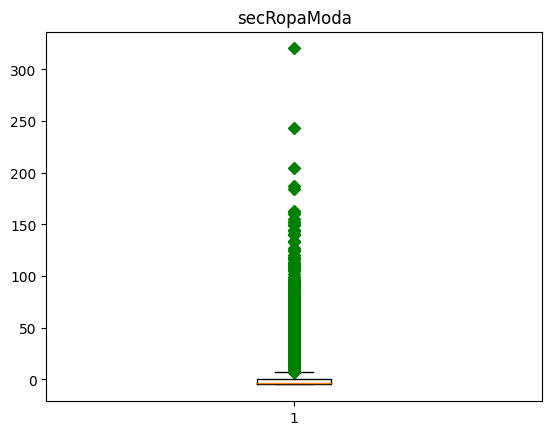

/tmp/ipython-input-2568220180.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dataFrame[columnName], 0, 'gD')


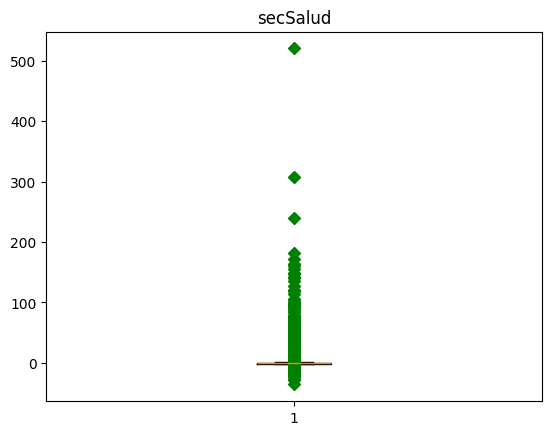

/tmp/ipython-input-2568220180.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dataFrame[columnName], 0, 'gD')


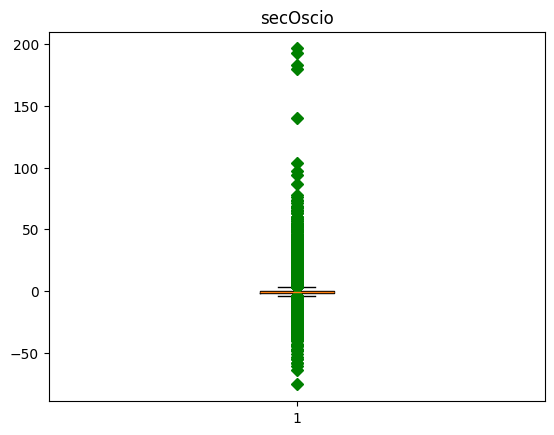

/tmp/ipython-input-2568220180.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dataFrame[columnName], 0, 'gD')


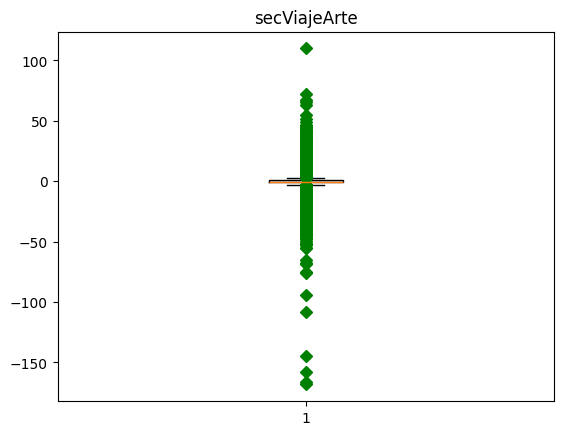

/tmp/ipython-input-2568220180.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dataFrame[columnName], 0, 'gD')


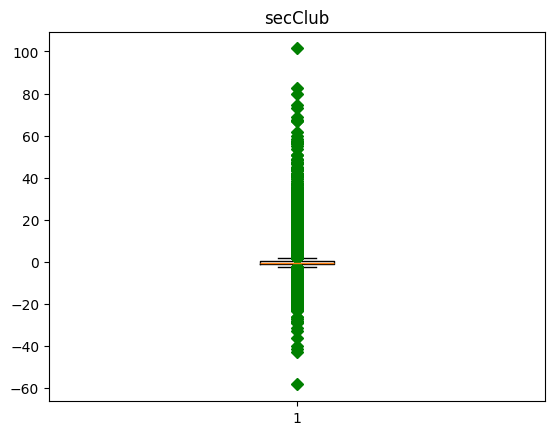

/tmp/ipython-input-2568220180.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dataFrame[columnName], 0, 'gD')


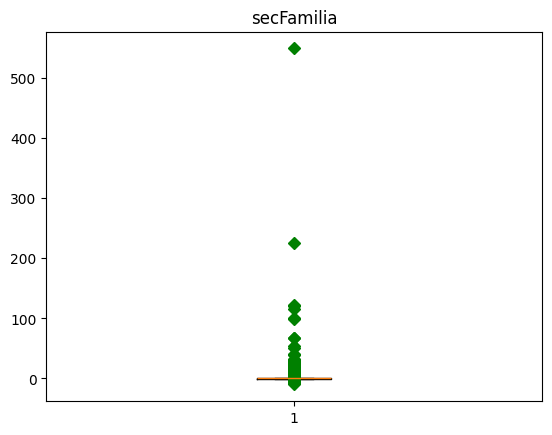

/tmp/ipython-input-2568220180.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dataFrame[columnName], 0, 'gD')


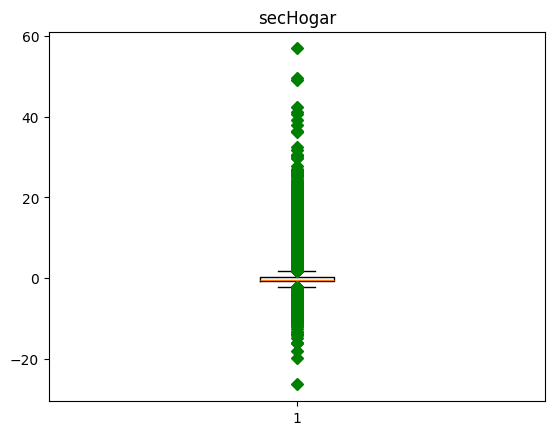

In [ ]:
for columnName in rubroNameComp:
    plt.title(columnName)
    plt.boxplot(dataFrame[columnName], 0, 'gD')
    plt.show()

In [ ]:
def deleteOutlier(df, col):
    dfClear = df.copy()
    for column in col:
        Q1 = dfClear[column].quantile(0.25)
        Q3 = dfClear[column].quantile(0.75)
        IQR = Q3 - Q1
        limiteInf = Q1 - 1.5 * IQR
        limiteSup = Q3 + 1.5 * IQR
        dfClear = dfClear[(dfClear[column] >= limiteInf) & (dfClear[column] <= limiteSup)]
    return dfClear

In [ ]:
dfPreFin = deleteOutlier(dataFrame,rubroNameComp)

/tmp/ipython-input-4014906968.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dfPreFin[columnName], 0, 'gD')


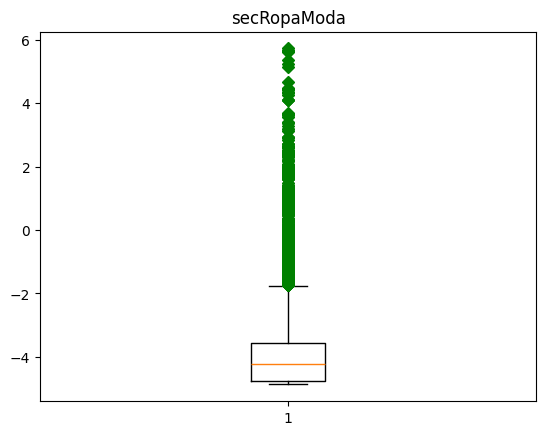

/tmp/ipython-input-4014906968.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dfPreFin[columnName], 0, 'gD')


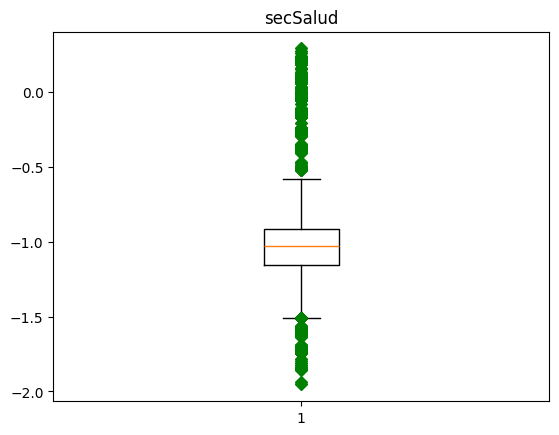

/tmp/ipython-input-4014906968.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dfPreFin[columnName], 0, 'gD')


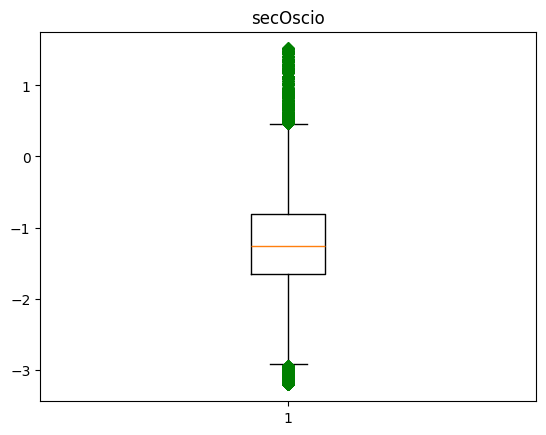

/tmp/ipython-input-4014906968.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dfPreFin[columnName], 0, 'gD')


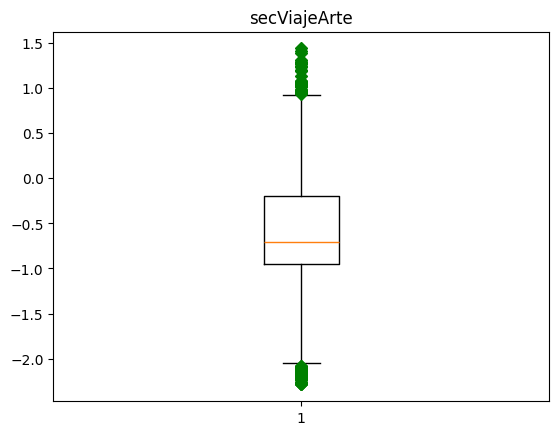

/tmp/ipython-input-4014906968.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dfPreFin[columnName], 0, 'gD')


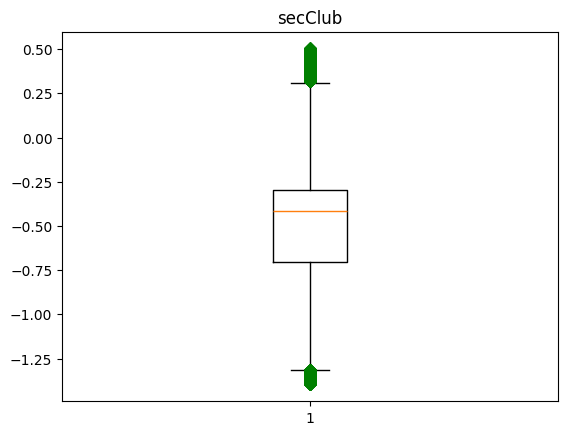

/tmp/ipython-input-4014906968.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dfPreFin[columnName], 0, 'gD')


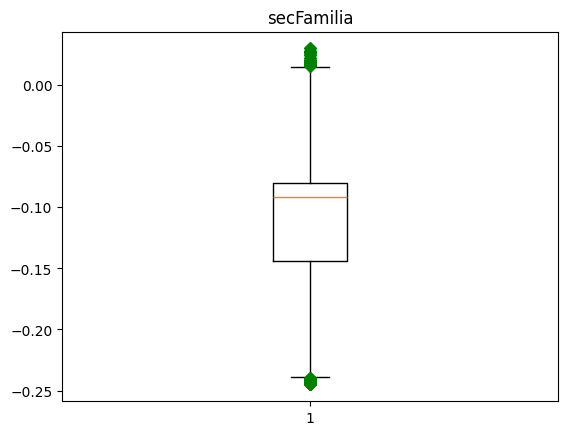

/tmp/ipython-input-4014906968.py:3: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.boxplot(dfPreFin[columnName], 0, 'gD')


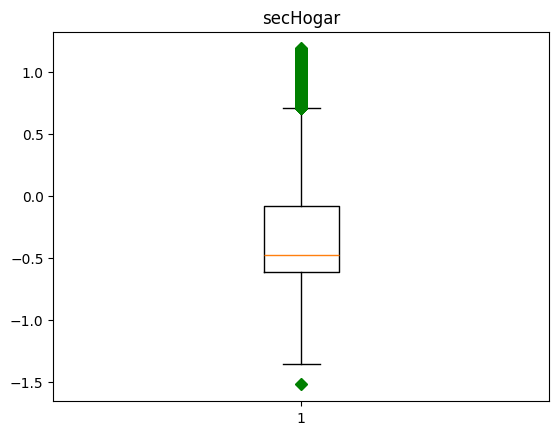

In [ ]:
for columnName in rubroNameComp:
    plt.title(columnName)
    plt.boxplot(dfPreFin[columnName], 0, 'gD')
    plt.show()

#### 3.3 Aplicando una segmentación

In [ ]:
from sklearn.cluster import KMeans
from sklearn import metrics

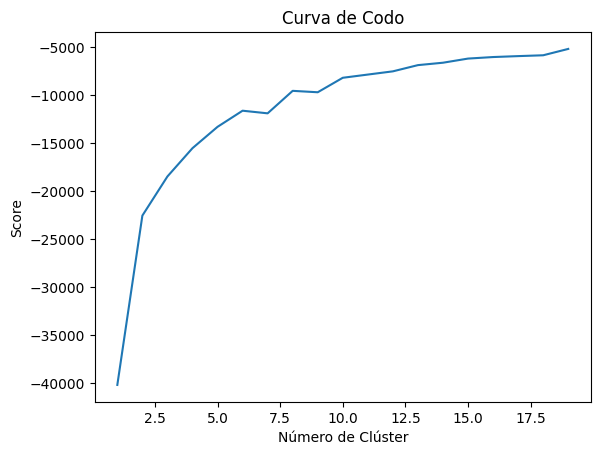

In [ ]:
# Calculando el número de clúster adecuado:
X = dfPreFin[rubroNameComp].copy()

numClus = range(1, 20)
kmeans = [KMeans(n_clusters=i,max_iter=600) for i in numClus]
kmeans
score = [kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(numClus,score)
plt.xlabel('Número de Clúster')
plt.ylabel('Score')
plt.title('Curva de Codo')
plt.show()

#### 3.4 Evaluación del segmento

In [ ]:
# Nos fijamos de los indicadores de clustering:

ctdDf = int(0.1*dfPreFin.shape[0])
cluster = [kmeans[i].predict(X) for i in range(len(kmeans))]

for i in range(1,11):
    print(str(i+1)+' clústeres:')
    print('Inercia: '+str(kmeans[i].inertia_))
    print('Silueta: '+str(metrics.silhouette_score(X, cluster[i], metric='euclidean',sample_size=ctdDf)))
    print("\n")

2 clústeres:
Inercia: 22541.402384029894
Silueta: 0.48586635770453585


3 clústeres:
Inercia: 18460.62279263927
Silueta: 0.34998976476468174


4 clústeres:
Inercia: 15511.340788036474
Silueta: 0.3337066451517286


5 clústeres:
Inercia: 13285.725826969001
Silueta: 0.37841747888396887


6 clústeres:
Inercia: 11603.692459737775
Silueta: 0.3635324395454586


7 clústeres:
Inercia: 11877.880143191493
Silueta: 0.2886043024100038


8 clústeres:
Inercia: 9532.693685894434
Silueta: 0.42019359341745643


9 clústeres:
Inercia: 9679.651681916273
Silueta: 0.3969675476598302


10 clústeres:
Inercia: 8169.922520347053
Silueta: 0.4276057570415548


11 clústeres:
Inercia: 7834.563280359563
Silueta: 0.4182565689271825




In [ ]:
numClus = [3,4,5,6,7,8]

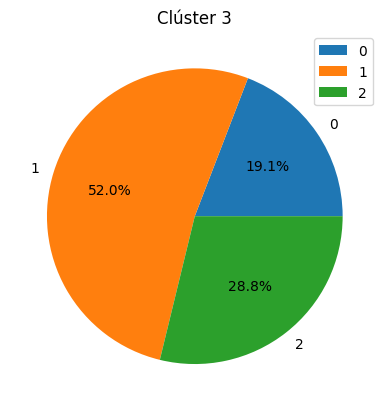

         ctdCliente  pctCliente
cluster                        
0              2769       19.15
1              7527       52.05
2              4164       28.80




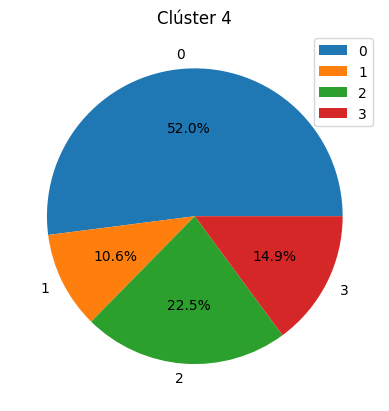

         ctdCliente  pctCliente
cluster                        
0              7524       52.03
1              1534       10.61
2              3247       22.46
3              2155       14.90




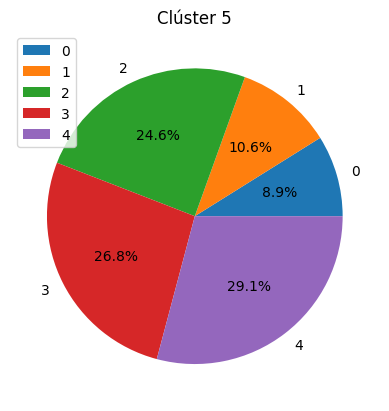

         ctdCliente  pctCliente
cluster                        
0              1285        8.89
1              1534       10.61
2              3559       24.61
3              3868       26.75
4              4214       29.14




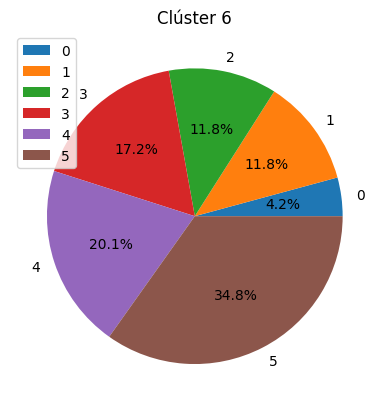

         ctdCliente  pctCliente
cluster                        
0               610        4.22
1              1701       11.76
2              1713       11.85
3              2491       17.23
4              2909       20.12
5              5036       34.83




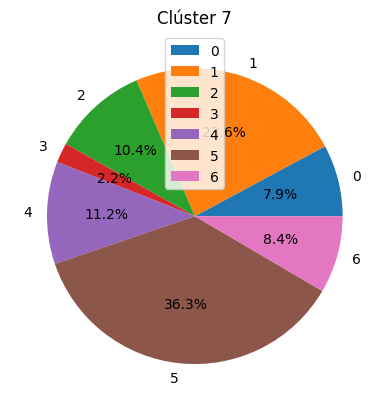

         ctdCliente  pctCliente
cluster                        
0              1135        7.85
1              3412       23.60
2              1505       10.41
3               312        2.16
4              1623       11.22
5              5252       36.32
6              1221        8.44




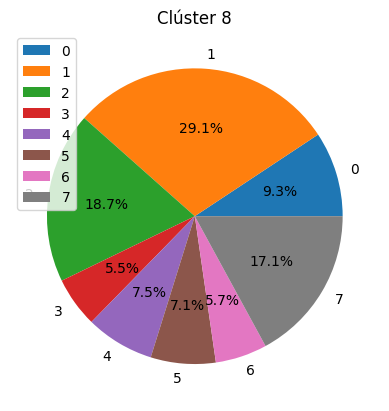

         ctdCliente  pctCliente
cluster                        
0              1346        9.31
1              4214       29.14
2              2710       18.74
3               795        5.50
4              1084        7.50
5              1026        7.10
6               818        5.66
7              2467       17.06




In [ ]:
centroide = [kmeans[i].cluster_centers_ for i in range(len(kmeans))]
copy =  pd.DataFrame()

for i in numClus:
    # Distribución de los grupos por clúster:
    copy['cluster'] = cluster[i-1]
    cantidadGrupo =  pd.DataFrame()
    cantidadGrupo['ctdCliente']=copy.groupby('cluster').size()
    cantidadGrupo['pctCliente']=round(100*cantidadGrupo['ctdCliente']/cantidadGrupo['ctdCliente'].sum(),2)

    # gráfico de los grupos según su distribución:
    plt.pie(cantidadGrupo['pctCliente'], labels=cantidadGrupo.index, autopct='%1.1f%%')
    plt.title('Clúster '+str(i))
    plt.legend()
    plt.show()
    print(cantidadGrupo)
    print('\n')

In [ ]:
df = pd.DataFrame()
df = dfPreFin.copy()

In [ ]:
nCluster = int(input('Ingrese la cantidad de cluster: '))
df['cluster'] = cluster[nCluster-1]

Ingrese la cantidad de cluster: 5


#### 3.5 Perfilamiento de Segmento

In [ ]:
import seaborn as sns

In [ ]:
# calculamos los centroides de los clusteres:
centroide = pd.DataFrame()

for columnName in rubroNameComp:
    centroide[columnName] = df.groupby('cluster').agg(columnName).mean()
centroide

,secRopaModa,secSalud,secOscio,secViajeArte,secClub,secFamilia,secHogar
cluster,,,,,,,
0,-4.369531,-0.952279,-0.239180,-1.401204,-0.373073,-0.100913,-0.423265
1,-0.913170,-1.317764,-2.155488,-1.100064,-0.618403,-0.090816,-0.379138
2,-3.584512,-1.132618,-1.674225,-0.923769,-0.387551,-0.084413,-0.360533
3,-4.070446,-0.815113,-0.701079,0.110067,-0.716039,-0.166927,-0.425218
4,-4.813880,-0.904817,-1.269271,-0.695917,-0.297402,-0.084357,-0.119143


  ******************************
       GRUPOS DEL CLUSTER 5
  ******************************


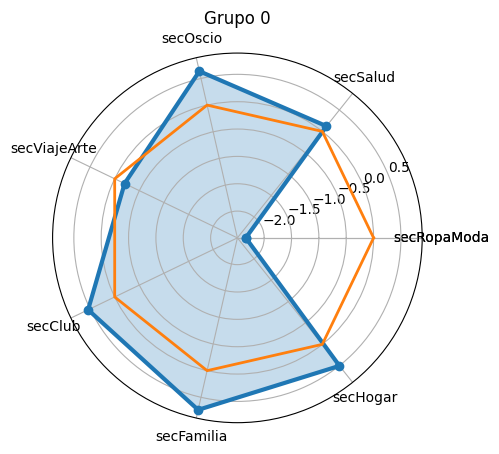

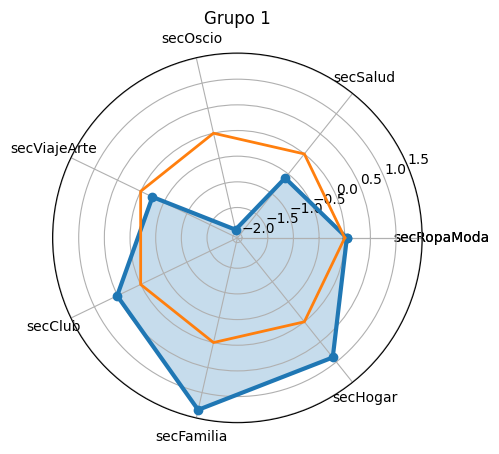

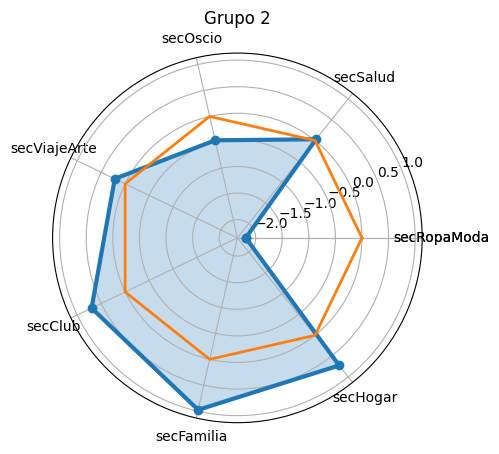

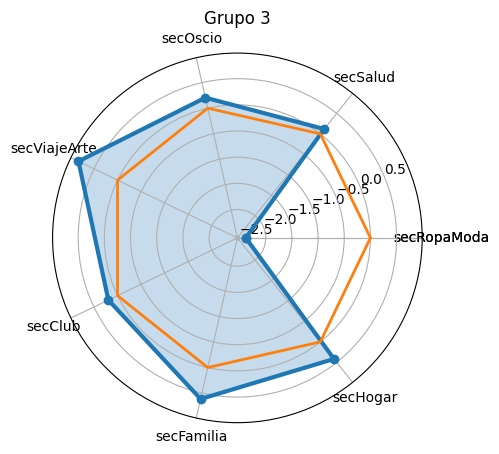

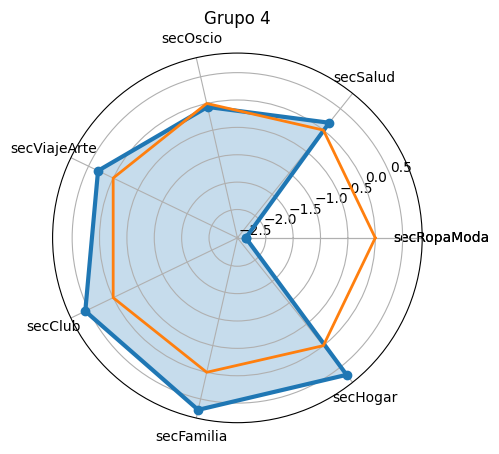

In [ ]:
print('  ******************************')
print('       GRUPOS DEL CLUSTER '+str(len(set(df['cluster']))))
print('  ******************************')

# Tener en cuenta el clúster con etiqueta "-1" que son los anómalos
indx = df.groupby(df['cluster']).count().index
label = rubroNameComp.copy()
label.append(rubroNameComp[0])

for i in indx:
    mu = centroide.loc[i].mean()
    dev= np.std(centroide.loc[i])

    stats=(centroide.loc[i].values-mu)/dev

    angles=np.linspace(0, 2*np.pi, len(rubroNameComp), endpoint=False)
    stats=np.concatenate((stats,[stats[0]]))
    ref = [0]*(len(rubroNameComp)+1)
    angles=np.concatenate((angles,[angles[0]]))

    fig=plt.figure()
    ax = fig.add_subplot(111, polar=True)
    ax.plot(angles, stats, 'o-', linewidth=3)
    ax.plot(angles, ref, '-', linewidth=2)

    ax.fill(angles, stats, alpha=0.25)
    ax.set_thetagrids(angles * 180/np.pi, labels = label)
    ax.grid(True)
    ax.set_title('Grupo '+str(i)+'\n')


#### 3.6 Descripción de Perfil

In [ ]:
resClus = df.groupby('cluster').agg({'cliente':'count','prodsuper':'mean','salud':'mean','vehrep':'mean','restbar':'mean','ropamoda':'mean',
                                     'clubmkt':'mean','artcultura':'mean'}).sort_values(by='cluster')

resClus = resClus.reset_index()
resClus['%'] = round(100*resClus['cliente']/df.count()[0],1)
print(f'Clientes Total: {df.count()[0]}\n')
resClus

Clientes Total: 14460



/tmp/ipython-input-856947970.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resClus['%'] = round(100*resClus['cliente']/df.count()[0],1)
/tmp/ipython-input-856947970.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Clientes Total: {df.count()[0]}\n')


,cluster,cliente,prodsuper,salud,vehrep,restbar,ropamoda,clubmkt,artcultura,%
0,0,1285,0.223346,0.042023,1.304280,0.277043,0.107393,0.098054,0.012451,8.9
1,1,1534,3.999348,0.310952,0.132986,0.643416,0.277053,0.093872,0.026728,10.6
2,2,3559,1.341107,0.089632,0.019387,0.091318,0.128407,0.060691,0.010677,24.6
3,3,3868,0.348759,0.121768,0.028180,1.302223,0.227249,0.095398,0.030507,26.7
4,4,4214,0.000000,0.000237,0.000000,0.000000,0.256051,0.296868,0.056478,29.1


#### 3.7 Visualización y Propuesta de Migración de Segmento

In [ ]:
!pip install somoclu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for somoclu: filename=somoclu-1.7.6-cp312-cp312-linux_x86_64.whl size=236133 sha256=6efb82584ce068dee855480819e3f2a2ec090b18deeece06fe05cc44ad7f0fef
  Stored in directory: /root/.cache/pip/wheels/8b/05/0a/6a22a13f926542d613ce2eb4b136884b1df7deecc20ec93c8f
Successfully built somoclu


In [ ]:
# Ingresar a la Terminal de Jupiter e installar el paquete "somoclu"
# pip install somoclu
import somoclu

In [ ]:
npData = df[rubroNameComp]
dfCluster=pd.DataFrame(df['cluster'])

dfCluster.loc[dfCluster["cluster"]== 0]='red'
dfCluster.loc[dfCluster["cluster"]== 1]='blue'
dfCluster.loc[dfCluster["cluster"]== 2]='green'
dfCluster.loc[dfCluster["cluster"]== 3]='cyan'
dfCluster.loc[dfCluster["cluster"]== 4]='yellow'

npData = np.array(npData)
listCluster = list(dfCluster["cluster"])
labels=range(df.shape[0])

/tmp/ipython-input-1719305018.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'red' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dfCluster.loc[dfCluster["cluster"]== 0]='red'


In [ ]:
som = somoclu.Somoclu(200, 200, data=npData)
%time som.train()

CPU times: user 10min 48s, sys: 1.94 s, total: 10min 50s
Wall time: 6min 30s


Esta visualización no s ayuda a ver cómo un segmento podría migrar a otro segmento según a la estrategia comercial que la empresa quisiera gestionar.

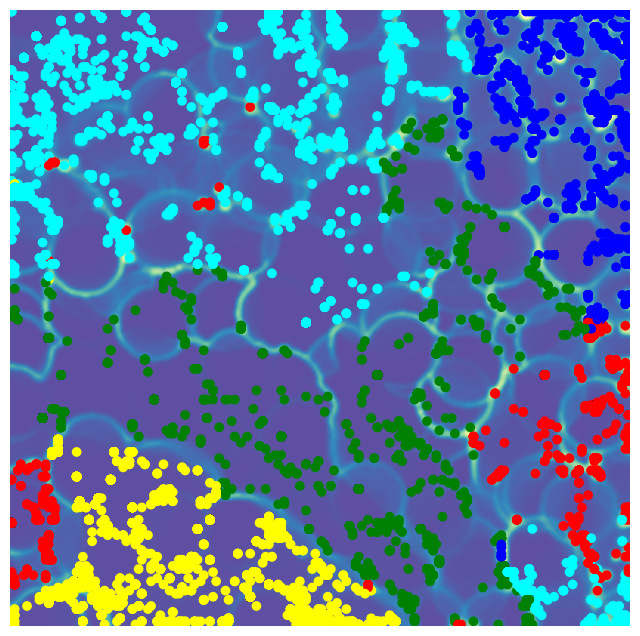

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

In [ ]:
som.view_umatrix(bestmatches=True, bestmatchcolors=listCluster)